<a href="https://colab.research.google.com/github/sathar1919/Data-Science-Projects/blob/main/EDA_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Capstone Project:**

A company wants to study the demographic data to make predictions about the earning potential of the population. However, the data gathered is not clean for analysis.


The company requests you, as a data scientist, to perform the following operations and gain some insights from the dat
a for data driven competitive advantage.

Remove data with missing values

Remove outliers

Establish the importance of the weekly working hours on earning potential

Find the features that are highly correlated with the earning potential

Find the relation between the number of years spent to get the degree and earning potential

Find the relationship between age and earning potential



In [1]:
#import Lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
file_path = '/content/drive/MyDrive/Datasets/Adult Dataset/adult.data'

# The dataset typically does not have a header, so we provide column names manually
# These column names are standard for the 'Adult' dataset
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv(file_path, header=None, names=column_names, na_values='?')


In [6]:
print(df)

       age          workclass  fnlwgt    education  education-num  \
0       39          State-gov   77516    Bachelors             13   
1       50   Self-emp-not-inc   83311    Bachelors             13   
2       38            Private  215646      HS-grad              9   
3       53            Private  234721         11th              7   
4       28            Private  338409    Bachelors             13   
...    ...                ...     ...          ...            ...   
32556   27            Private  257302   Assoc-acdm             12   
32557   40            Private  154374      HS-grad              9   
32558   58            Private  151910      HS-grad              9   
32559   22            Private  201490      HS-grad              9   
32560   52       Self-emp-inc  287927      HS-grad              9   

            marital-status          occupation    relationship    race  \
0            Never-married        Adm-clerical   Not-in-family   White   
1       Married-civ-spo

In [7]:
print(df.head)

<bound method NDFrame.head of        age          workclass  fnlwgt    education  education-num  \
0       39          State-gov   77516    Bachelors             13   
1       50   Self-emp-not-inc   83311    Bachelors             13   
2       38            Private  215646      HS-grad              9   
3       53            Private  234721         11th              7   
4       28            Private  338409    Bachelors             13   
...    ...                ...     ...          ...            ...   
32556   27            Private  257302   Assoc-acdm             12   
32557   40            Private  154374      HS-grad              9   
32558   58            Private  151910      HS-grad              9   
32559   22            Private  201490      HS-grad              9   
32560   52       Self-emp-inc  287927      HS-grad              9   

            marital-status          occupation    relationship    race  \
0            Never-married        Adm-clerical   Not-in-family   Wh

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [11]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [9]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
#Remove Data with Missing Values
#In the Adult dataset, missing values are usually represented by " ?".
df.replace(" ?", np.nan, inplace=True)
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [12]:
#Remove missing values.
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [14]:
#Remove Outliers
#Remove outliers from numerical columns using the IQR method.
num_cols = ['age','fnlwgt','education-num',
            'capital-gain','capital-loss','hours-per-week']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]


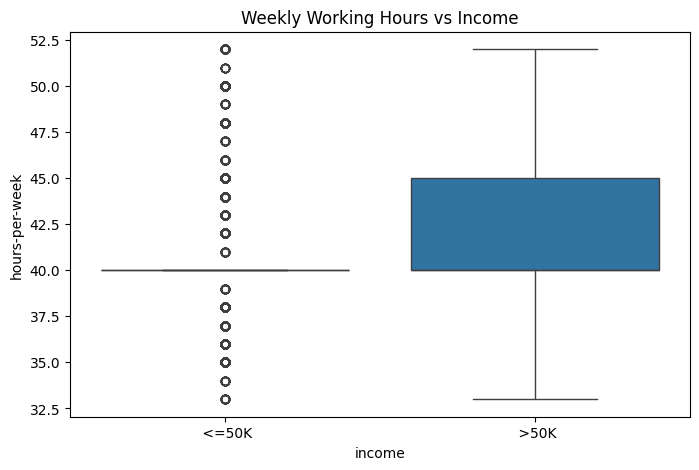

In [15]:
#Establish the Importance of Weekly Working Hours on Earning Potential
plt.figure(figsize=(8,5))
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title("Weekly Working Hours vs Income")
plt.show()

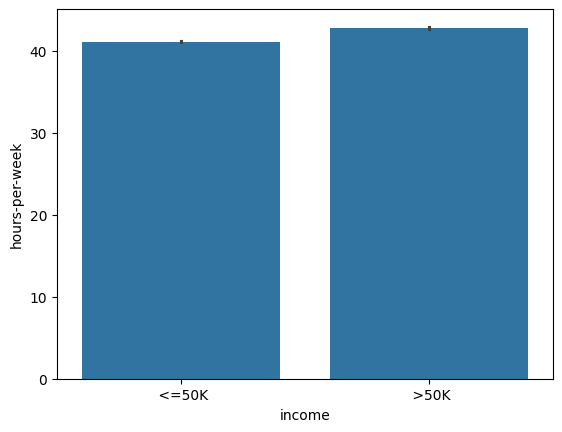

In [16]:
sns.barplot(x='income',
            y='hours-per-week',
            data=df)
plt.show()

In [18]:
#Find Features Highly Correlated with Earning Potential
#Convert categorical variables into numeric.
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = label.fit_transform(df_encoded[col])

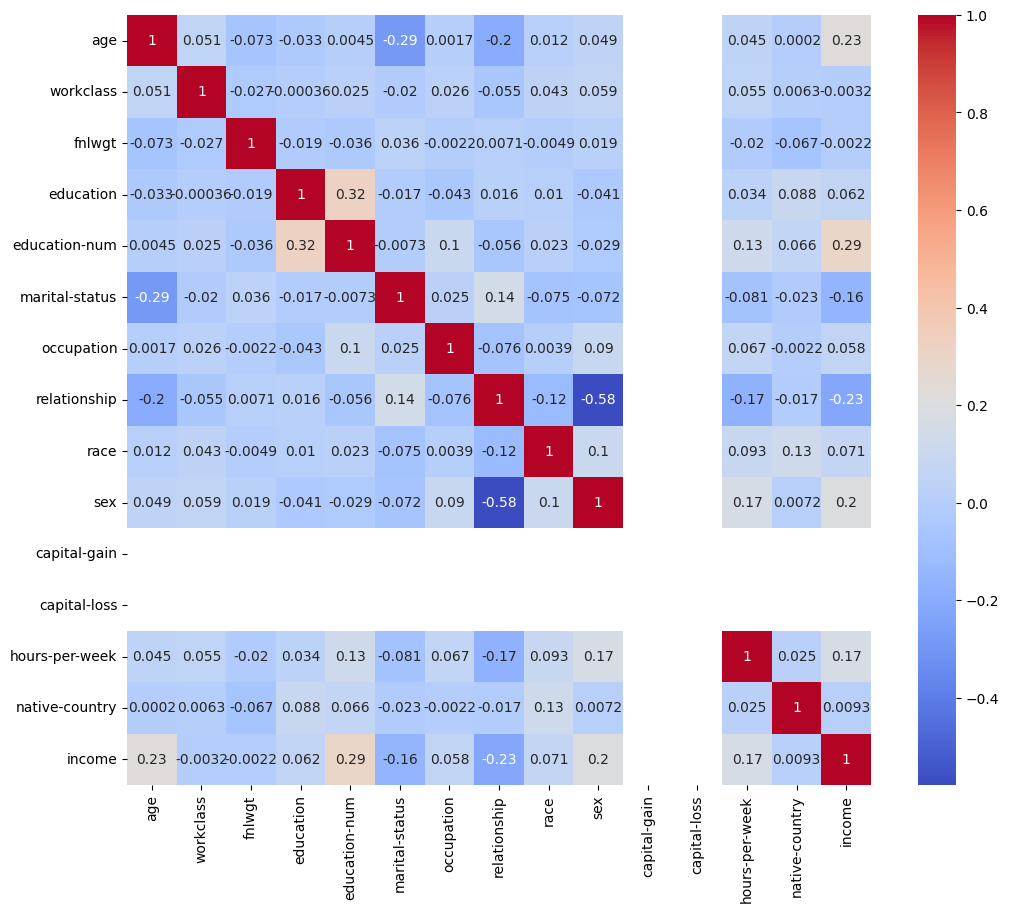

In [19]:
#correlation Matrix
corr = df_encoded.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [20]:
#Income correlation
corr['income'].sort_values(ascending=False)

,income
income,1.000000
education-num,0.291560
age,0.234187
sex,0.198573
hours-per-week,0.172677
race,0.070700
education,0.062350
occupation,0.057827
native-country,0.009307
fnlwgt,-0.002178
